In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os


In [13]:
start=1000
end=100000
interval=1000

list_of_errs = []
list_of_steps = []
for step in range(start, end+interval, interval):
    path = f"/home/sultand/interleaved_time_series/TFs_do_KF_ICL/outputs/llama/251217_212211.ccb107_multi_sys_trace_zero_cut_ortho_haar_state_dim_5_ident_C_lr_0.001_num_train_sys_40000/prediction_errors_ident_C_step={step}.ckpt/train_conv_zero_cut_mult_cut_val_ortho_haar_state_dim_5_err_lss_examples.pkl"

    if os.path.exists(path):
        #load the pickle file
        err_lss = np.load(path, allow_pickle=True)["MOP"]
        list_of_errs.append(err_lss)
        list_of_steps.append(step)

list_of_errs: (1, 100, 1000, 251)
i: 0, step: 1000


/home/sultand/.conda/envs/myenv310/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


i: 1, step: 6000
i: 2, step: 11000
i: 3, step: 16000
i: 4, step: 21000
i: 5, step: 26000
i: 6, step: 31000
i: 7, step: 37000
i: 8, step: 47000
i: 9, step: 57000
i: 10, step: 67000
i: 11, step: 77000
i: 12, step: 87000
i: 13, step: 97000


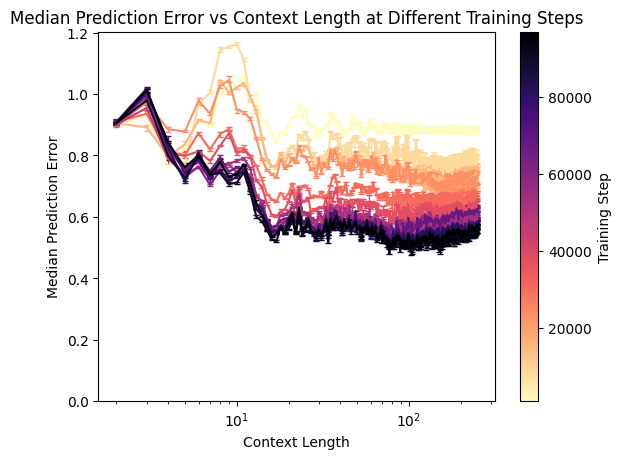

In [20]:
#plot the list of errs
fig, ax = plt.subplots()


#skip every 10 steps
skip = 5
colors = plt.cm.magma(np.linspace(0, 1, int(len(list_of_errs)/skip) + 1))

print(f"list_of_errs: {list_of_errs[0].shape}")
context = list_of_errs[0].shape[-1]
for i, err in enumerate(list_of_errs[::skip]):
    step = list_of_steps[i*skip]
    print(f"i: {i}, step: {step}")


    med = np.median(err[0], axis=1)

    quartiles = np.percentile(med, [25,50, 75], axis=0)
    ax.errorbar(range(context), quartiles[1], yerr=[quartiles[1]-quartiles[0], quartiles[2]-quartiles[1]], label=f"step={step}", color=colors[int(len(list_of_errs)/skip) - i], elinewidth=1, capsize=2)

ax.set_xlabel("Context Length")
ax.set_ylabel("Median Prediction Error")
ax.set_title("Median Prediction Error vs Context Length at Different Training Steps")
ax.set_xscale("log")
ax.set_ylim(0, None)
# Colorbar for step progression
norm = mcolors.Normalize(vmin=list_of_steps[0], vmax=list_of_steps[-1])
#flip magma so earlier steps are lighter
cmap = plt.cm.magma.reversed()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Training Step')


# ax.legend()
plt.show()